# Chilling Ending Evaluation — Results Visualization

This notebook visualizes the prediction-based evaluation of chilling endings across 6 short stories.

**Pipeline**: For each of 5 ending lengths, we truncate the story and independently generate 5 possible endings (temperature=1.0). We then compare these generated endings to the actual ending via:
1. **Embedding distance** (cosine, Qwen3-Embedding-0.6B) — higher = less predictable
2. **LLM judge similarity** (0-10 scale) — higher = more predictable

Stories are labeled by expected chill level: **high** (Poor Girl, Ladies' Lunch), **moderate** (Two Ruminations), **low** (The Fellow, Snowing, Martians).


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Load results
with open("results/batch_summary.json") as f:
    data = json.load(f)

# Organize by story
stories = []
for sid, info in data.items():
    stories.append({
        "id": sid,
        "title": info["title"],
        "expected": info["expected"],
        "levels": info["levels"],
    })

# Sort: high first, then moderate, then low
order = {"high": 0, "moderate": 1, "low": 2}
stories.sort(key=lambda s: (order[s["expected"]], s["title"]))

print(f"Loaded {len(stories)} stories")
for s in stories:
    n_levels = len(s["levels"])
    print(f"  {s['title']:<30} expected={s['expected']:<8} levels={n_levels}")


Loaded 6 stories
  Ladies' Lunch                  expected=high     levels=5
  Poor Girl                      expected=high     levels=5
  Two Ruminations                expected=moderate levels=5
  Invasion of the Martians       expected=low      levels=5
  Snowing in Greenwich Village   expected=low      levels=5
  The Fellow                     expected=low      levels=5


## Summary Table

Raw scores across all ending lengths and stories.


In [2]:
# Summary table
header = f"{'Story':<30} {'Exp':<8} {'End%':>6} {'Sents':>5} {'Emb-Mean':>9} {'Emb-Min':>9} {'LLM-Mean':>9} {'LLM-Max':>9}"
print(header)
print("-" * len(header))
for s in stories:
    for lv in s["levels"]:
        if "error" in lv:
            continue
        if lv["level"] == 1:
            print(f"\n{s['title']:<30} {s['expected']:<8}", end="")
        else:
            print(f"{'':38}", end="")
        print(f" {lv['ending_pct']:>5.1f}% {lv['n_sentences']:>5} "
              f"{lv['embedding_mean']:>9.4f} {lv['embedding_min']:>9.4f} "
              f"{lv['llm_mean']:>9.1f} {lv['llm_max']:>9.1f}")


Story                          Exp        End% Sents  Emb-Mean   Emb-Min  LLM-Mean   LLM-Max
--------------------------------------------------------------------------------------------

Ladies' Lunch                  high       6.4%     9    0.4571    0.3746       4.0       6.0
                                        10.1%    17    0.5690    0.4987       2.2       3.0
                                        13.4%    25    0.4082    0.3375       4.4       6.0
                                        16.8%    33    0.7151    0.6555       2.5       3.0
                                        20.6%    41    0.3248    0.2856       3.8       4.0

Poor Girl                      high       6.2%     6    0.4134    0.3667       4.0       5.0
                                         8.7%    11    0.4004    0.3446       4.2       5.0
                                        12.8%    16    0.3921    0.3370       4.4       6.0
                                        16.6%    21    0.4037    0.3410   

## Ending Unpredictability Across the Narrative

X-axis = reader's progress through the story (left = earlier truncation, right = just before the final sentences). Y-axis = how different the model's predicted endings are from what actually happens.

**Embedding distance** (higher = less predictable): A chilling ending should remain **unpredictable even late in the story** (right side), while a predictable ending should converge (distance drops) as we approach the end.


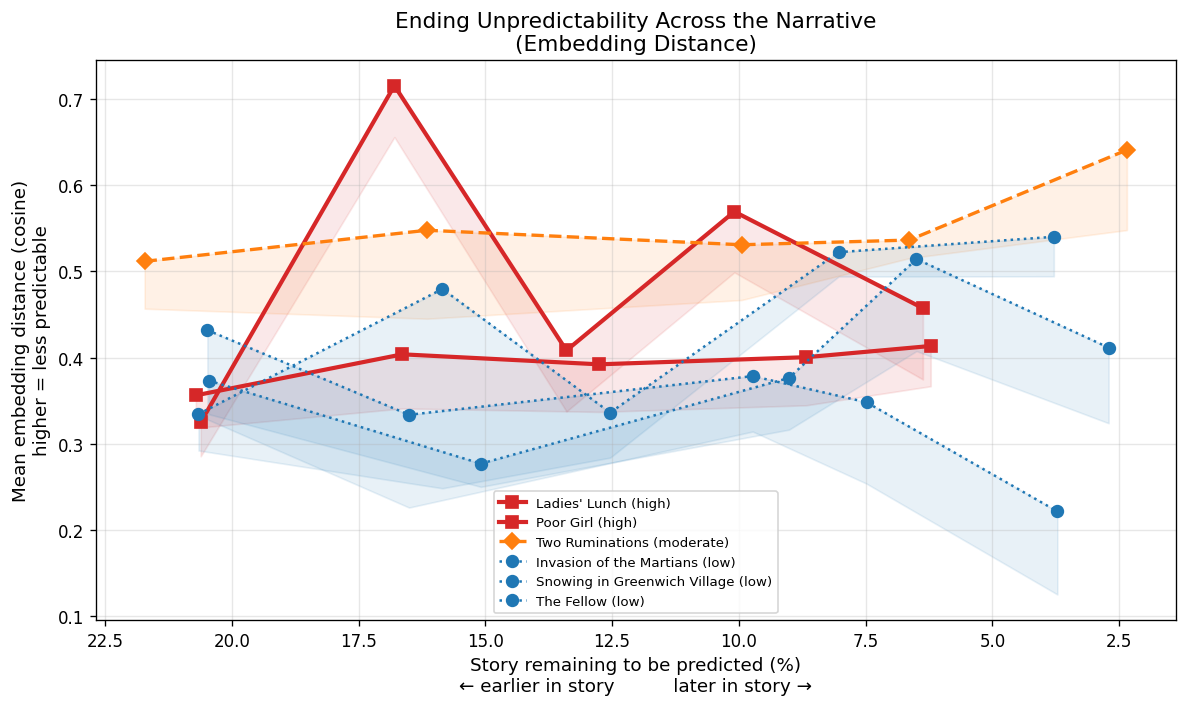

In [3]:
# Color/style by expected category
style_map = {
    "high":     {"color": "#d62728", "marker": "s", "lw": 2.5, "ls": "-"},
    "moderate": {"color": "#ff7f0e", "marker": "D", "lw": 2.0, "ls": "--"},
    "low":      {"color": "#1f77b4", "marker": "o", "lw": 1.5, "ls": ":"},
}

fig, ax = plt.subplots(figsize=(10, 6))

for s in stories:
    levels_data = [lv for lv in s["levels"] if "error" not in lv]
    # Reverse: chunk 5 (earliest) on left, chunk 1 (latest) on right
    pcts = [lv["ending_pct"] for lv in reversed(levels_data)]
    emb_means = [lv["embedding_mean"] for lv in reversed(levels_data)]
    emb_mins = [lv["embedding_min"] for lv in reversed(levels_data)]

    st = style_map[s["expected"]]
    label = f"{s['title']} ({s['expected']})"

    ax.plot(pcts, emb_means, marker=st["marker"], color=st["color"],
            linewidth=st["lw"], linestyle=st["ls"], label=label, markersize=7)
    ax.fill_between(pcts, emb_mins, emb_means, alpha=0.1, color=st["color"])

ax.set_xlabel("Story remaining to be predicted (%)\n← earlier in story          later in story →", fontsize=11)
ax.set_ylabel("Mean embedding distance (cosine)\nhigher = less predictable", fontsize=11)
ax.set_title("Ending Unpredictability Across the Narrative\n(Embedding Distance)", fontsize=13)
ax.invert_xaxis()  # largest % (earliest truncation) on left
ax.legend(fontsize=8, loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## LLM Judge Similarity Across the Narrative

Same reading-order x-axis. **LLM similarity** (higher = more predictable): For a predictable story, similarity should **increase** as we approach the ending (right side). For a chilling ending, it should stay low — the model never converges on the actual ending.


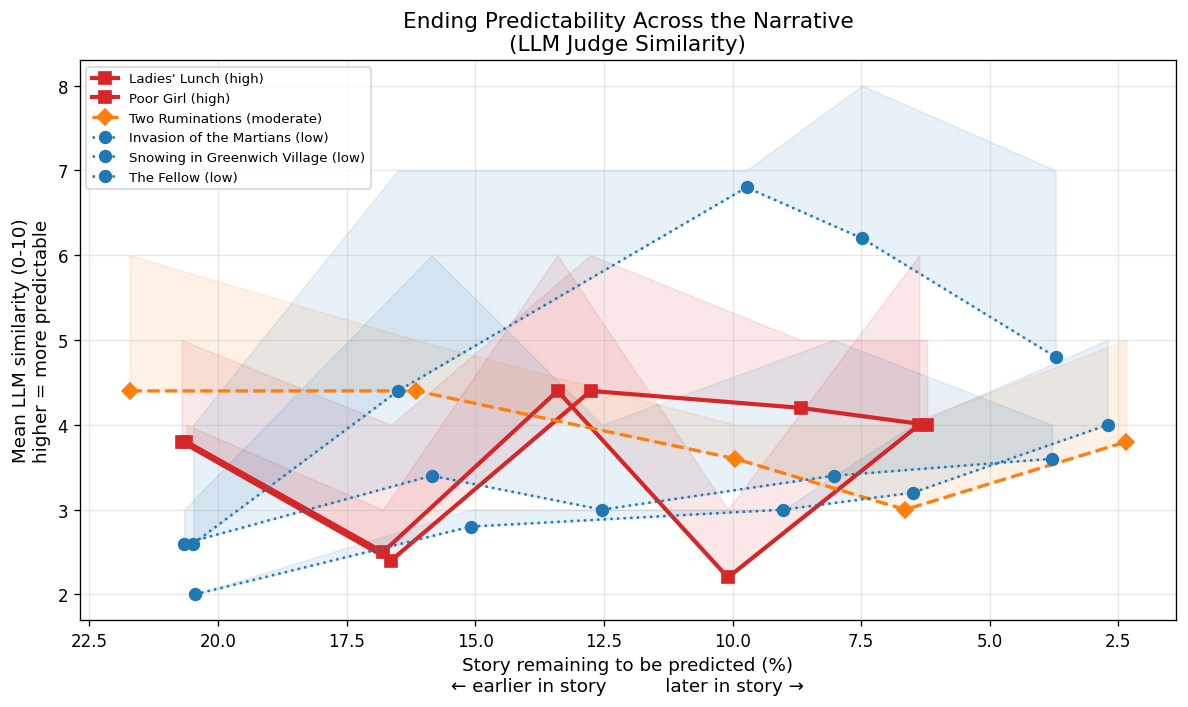

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for s in stories:
    levels_data = [lv for lv in s["levels"] if "error" not in lv]
    pcts = [lv["ending_pct"] for lv in reversed(levels_data)]
    llm_means = [lv["llm_mean"] for lv in reversed(levels_data)]
    llm_maxs = [lv["llm_max"] for lv in reversed(levels_data)]

    st = style_map[s["expected"]]
    label = f"{s['title']} ({s['expected']})"

    ax.plot(pcts, llm_means, marker=st["marker"], color=st["color"],
            linewidth=st["lw"], linestyle=st["ls"], label=label, markersize=7)
    ax.fill_between(pcts, llm_means, llm_maxs, alpha=0.1, color=st["color"])

ax.set_xlabel("Story remaining to be predicted (%)\n← earlier in story          later in story →", fontsize=11)
ax.set_ylabel("Mean LLM similarity (0-10)\nhigher = more predictable", fontsize=11)
ax.set_title("Ending Predictability Across the Narrative\n(LLM Judge Similarity)", fontsize=13)
ax.invert_xaxis()
ax.legend(fontsize=8, loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Distribution of Individual Scores

Each point on the curves above is a mean of 5 independent generations. The boxplots show variance — wider boxes indicate the model is uncertain about what direction the ending should take.


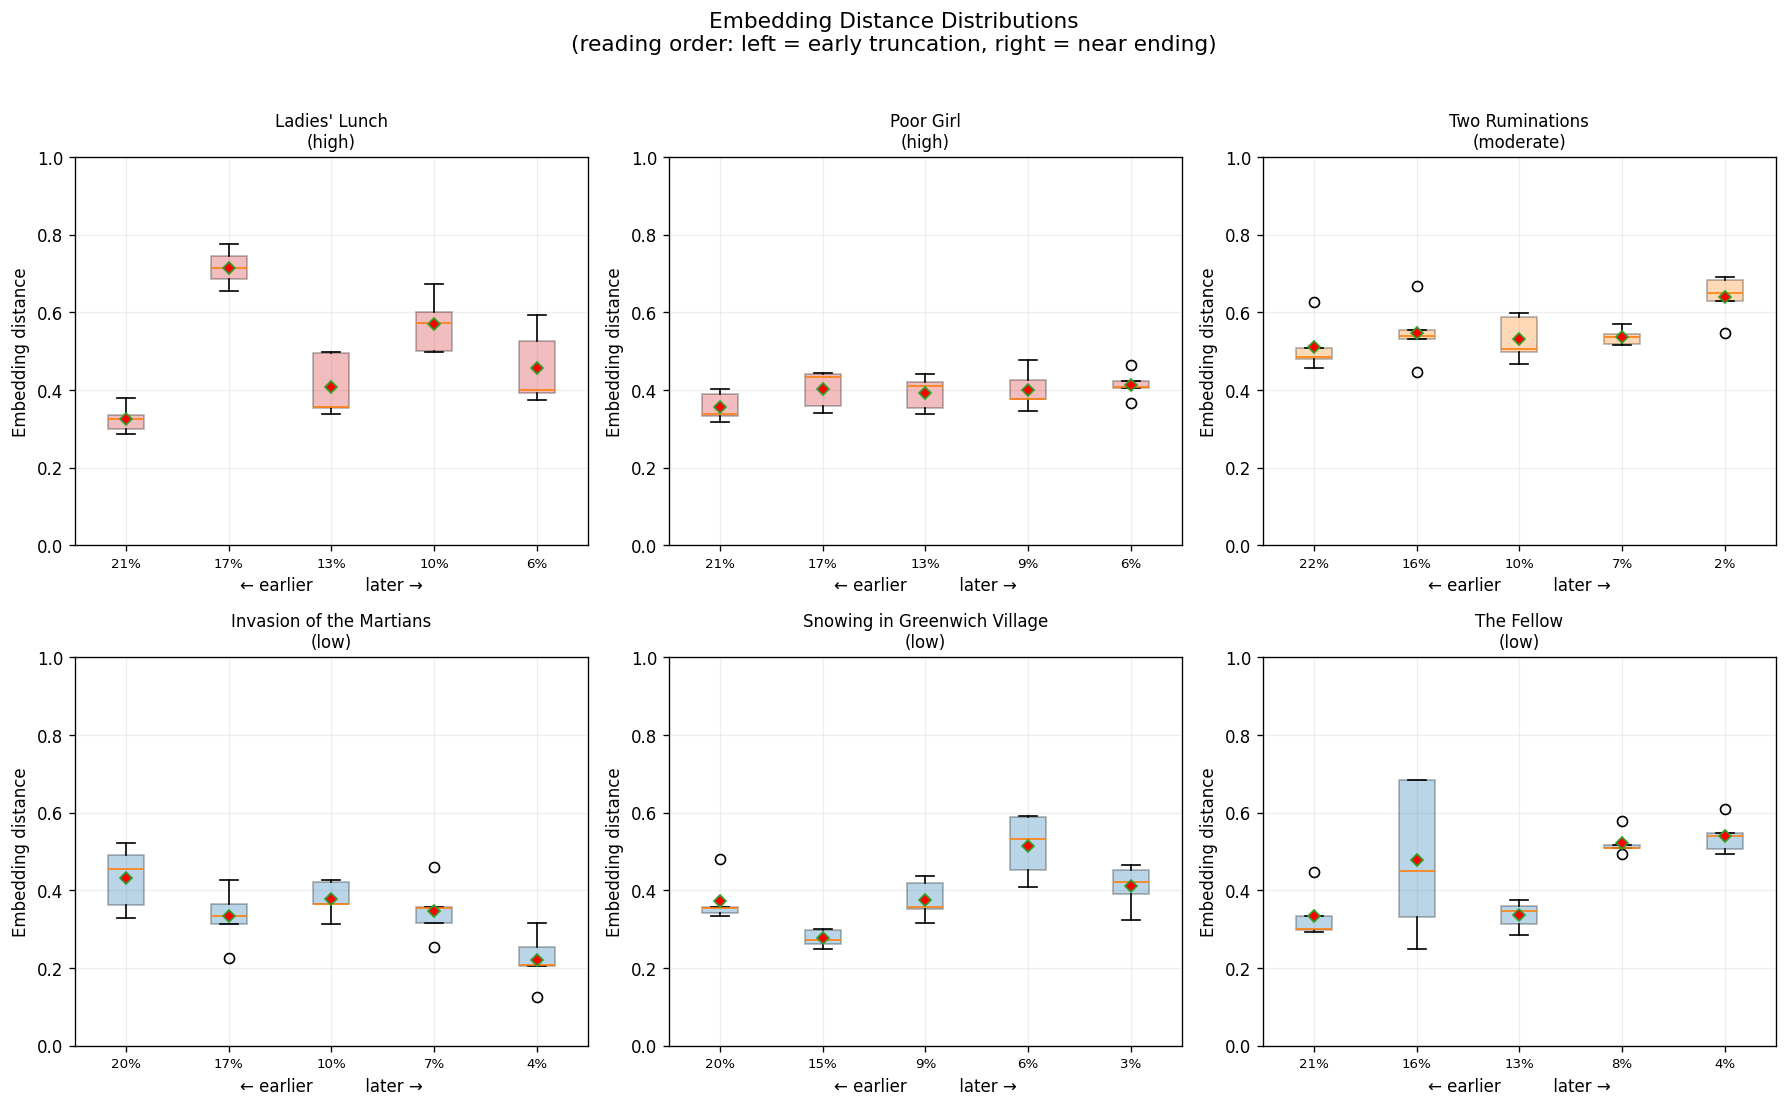

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, s in enumerate(stories):
    ax = axes[idx]
    levels_data = [lv for lv in s["levels"] if "error" not in lv]

    # Reverse order: reading progression left to right
    emb_data = [lv["embedding_distances"] for lv in reversed(levels_data)]
    pct_labels = [f"{lv['ending_pct']:.0f}%" for lv in reversed(levels_data)]
    positions = list(range(1, len(emb_data) + 1))

    bp = ax.boxplot(emb_data, positions=positions, widths=0.35,
                    patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='red', markersize=5))
    for patch in bp['boxes']:
        patch.set_facecolor(style_map[s["expected"]]["color"])
        patch.set_alpha(0.3)

    ax.set_title(f"{s['title']}\n({s['expected']})", fontsize=10)
    ax.set_xlabel("← earlier          later →")
    ax.set_ylabel("Embedding distance")
    ax.set_xticks(positions)
    ax.set_xticklabels(pct_labels, fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.set_ylim(0, 1.0)

fig.suptitle("Embedding Distance Distributions\n(reading order: left = early truncation, right = near ending)",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## LLM Similarity Distributions


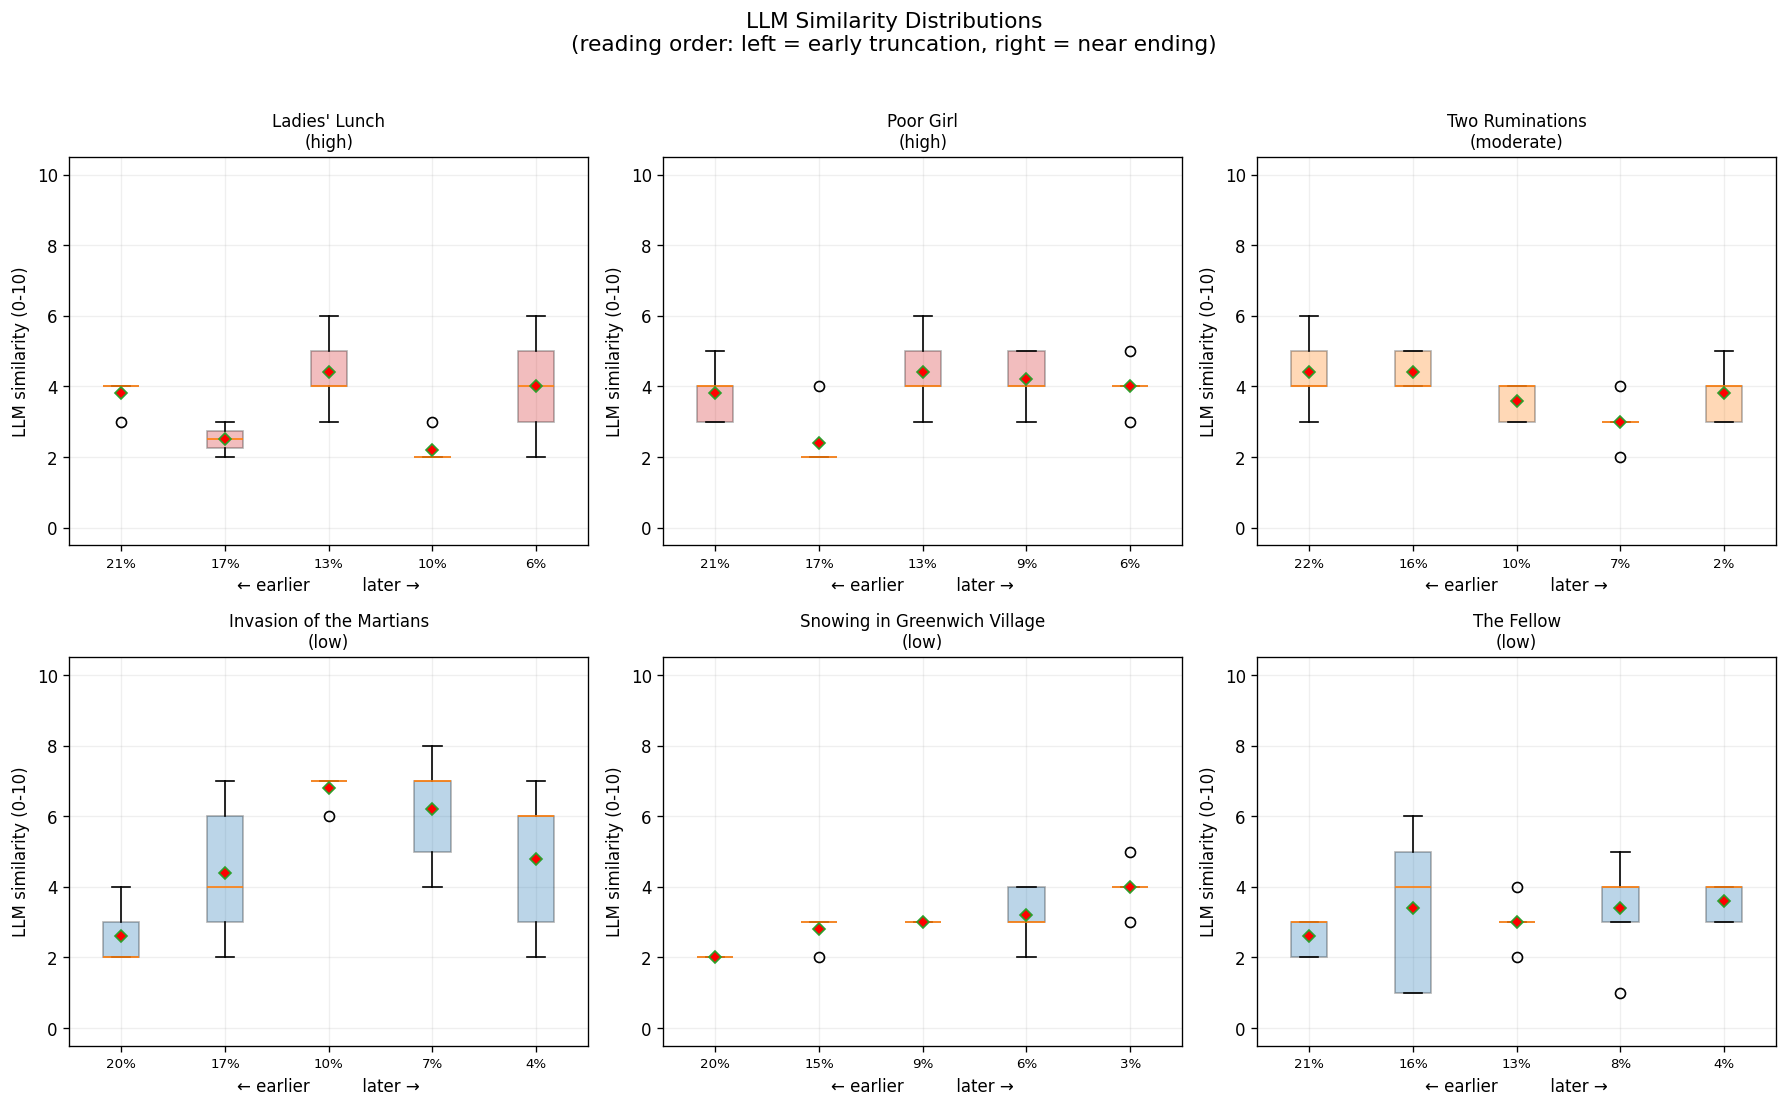

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, s in enumerate(stories):
    ax = axes[idx]
    levels_data = [lv for lv in s["levels"] if "error" not in lv]

    llm_data = [lv["llm_scores"] for lv in reversed(levels_data) if lv.get("llm_scores")]
    pct_labels = [f"{lv['ending_pct']:.0f}%" for lv in reversed(levels_data) if lv.get("llm_scores")]
    positions = list(range(1, len(llm_data) + 1))

    if not llm_data:
        ax.text(0.5, 0.5, "No LLM scores", transform=ax.transAxes, ha='center')
        continue

    bp = ax.boxplot(llm_data, positions=positions, widths=0.35,
                    patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='red', markersize=5))
    for patch in bp['boxes']:
        patch.set_facecolor(style_map[s["expected"]]["color"])
        patch.set_alpha(0.3)

    ax.set_title(f"{s['title']}\n({s['expected']})", fontsize=10)
    ax.set_xlabel("← earlier          later →")
    ax.set_ylabel("LLM similarity (0-10)")
    ax.set_xticks(positions)
    ax.set_xticklabels(pct_labels, fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.set_ylim(-0.5, 10.5)

fig.suptitle("LLM Similarity Distributions\n(reading order: left = early truncation, right = near ending)",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## Average Scores Across All Ending Lengths

Aggregate view: mean embedding distance and mean LLM similarity per story, averaged across all 5 ending lengths. This gives a single "predictability" score per story.


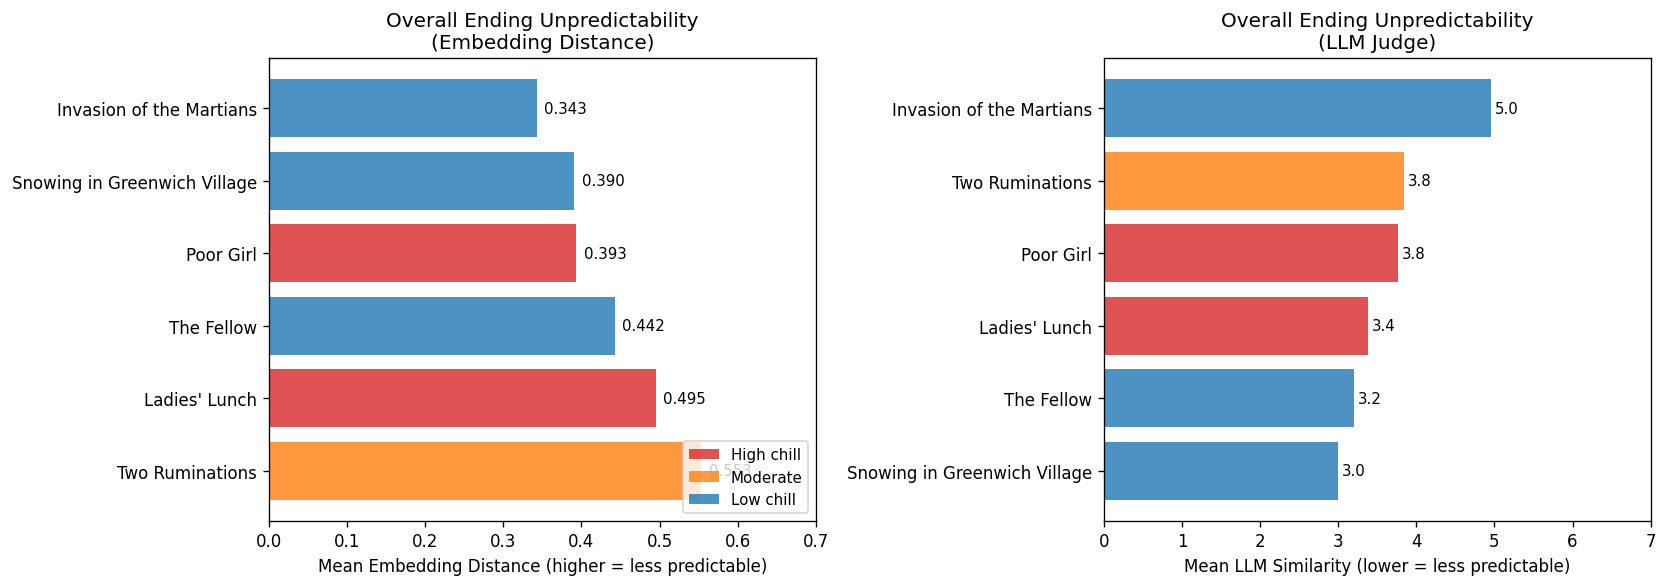

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

titles = []
emb_avgs = []
llm_avgs = []
colors = []

for s in stories:
    levels_data = [lv for lv in s["levels"] if "error" not in lv]
    titles.append(s["title"])
    emb_avgs.append(np.mean([lv["embedding_mean"] for lv in levels_data]))
    llm_avgs.append(np.mean([lv["llm_mean"] for lv in levels_data]))
    colors.append(style_map[s["expected"]]["color"])

# Sort by embedding distance descending
sort_idx = np.argsort(emb_avgs)[::-1]

# Embedding bar chart
bars1 = ax1.barh([titles[i] for i in sort_idx],
                 [emb_avgs[i] for i in sort_idx],
                 color=[colors[i] for i in sort_idx], alpha=0.8)
ax1.set_xlabel("Mean Embedding Distance (higher = less predictable)")
ax1.set_title("Overall Ending Unpredictability\n(Embedding Distance)")
ax1.set_xlim(0, 0.7)
for bar, idx in zip(bars1, sort_idx):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{emb_avgs[idx]:.3f}", va='center', fontsize=9)

# LLM bar chart (sort by LLM ascending = least predictable first)
sort_idx2 = np.argsort(llm_avgs)
bars2 = ax2.barh([titles[i] for i in sort_idx2],
                 [llm_avgs[i] for i in sort_idx2],
                 color=[colors[i] for i in sort_idx2], alpha=0.8)
ax2.set_xlabel("Mean LLM Similarity (lower = less predictable)")
ax2.set_title("Overall Ending Unpredictability\n(LLM Judge)")
ax2.set_xlim(0, 7)
for bar, idx in zip(bars2, sort_idx2):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f"{llm_avgs[idx]:.1f}", va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', alpha=0.8, label='High chill'),
                   Patch(facecolor='#ff7f0e', alpha=0.8, label='Moderate'),
                   Patch(facecolor='#1f77b4', alpha=0.8, label='Low chill')]
ax1.legend(handles=legend_elements, fontsize=9, loc='lower right')

fig.tight_layout()
plt.show()


## Key Takeaways

Reading the curves as **tension/unpredictability trajectories** through the narrative:

**What works:**
- **Martians** (low, blue) shows a clear convergence pattern on LLM similarity — predictability **rises** as we approach the ending (scores go from ~2.6 to ~6.8), meaning the model increasingly "sees it coming." This is the signature of a non-chilling, confirmatory ending.
- **Snowing** (low, blue) shows a similar convergence — LLM similarity rises from ~2.0 to ~4.0 as we approach the final scene.
- **Two Ruminations** (moderate, orange) stays consistently high on embedding distance (~0.5-0.6) across all points — the meta-narrative ending is hard to predict no matter how much of the story you've read.

**The reading-order framing matters:**
- These curves now read as narrative tension profiles. A story whose unpredictability **stays flat or rises** toward the end has a chilling ending. A story whose unpredictability **drops** toward the end has a predictable resolution.
- **Poor Girl** (high, red) maintains flat embedding distance (~0.35-0.41) all the way through — the model never converges on "the wife had an abortion, just in case."

**Remaining challenges:**
- **Ladies' Lunch** (high) shows noisy, non-monotonic patterns. Its ending operates through tonal confirmation rather than factual surprise.
- 5 generations per point produces high variance. More samples would smooth the curves.
- The LLM judge compresses scores into a narrow 2-5 range, limiting discriminative power.
